# TPX3 Decode Notebook

This notebook decodes `.tpx3` files using the layout described in `Timepix Documentation/tpx_file_decoding.md`.
It reads chunked payloads, applies the `2**62` shift, and decodes pixel and TDC packets.

Some files encode pixel and TDC headers as `0x2` and `0x1` after the shift. The decoder
auto-detects header pairs from the first chunk to handle both conventions.


In [1]:
import json
import struct
from dataclasses import dataclass
from typing import Iterable, List, Tuple


In [2]:
PIXEL_RES_NS = 25 / 16

@dataclass
class PixelData:
    time_ns: float
    x: int
    y: int
    tot: int

def iter_packets(path: str) -> Iterable[int]:
    with open(path, "rb") as f:
        while True:
            header = f.read(8)
            if not header:
                break
            if len(header) < 8:
                break
            payload_len = int.from_bytes(header[6:8], "little")
            if payload_len <= 0:
                continue
            payload = f.read(payload_len)
            if len(payload) < payload_len:
                break
            for offset in range(0, payload_len, 8):
                (word,) = struct.unpack_from("<Q", payload, offset)
                packet = (word - (1 << 62)) & ((1 << 64) - 1)
                yield packet

def detect_headers(path: str, sample_packets: int = 4096) -> Tuple[int, int]:
    headers = {}
    for packet in iter_packets(path):
        header = packet >> 60
        headers[header] = headers.get(header, 0) + 1
        if sum(headers.values()) >= sample_packets:
            break

    if 0x7 in headers and 0x2 in headers:
        return 0x7, 0x2
    if 0x2 in headers and 0x1 in headers:
        return 0x2, 0x1
    if headers:
        ordered = sorted(headers.items(), key=lambda kv: kv[1], reverse=True)
        if len(ordered) >= 2:
            return ordered[0][0], ordered[1][0]
        return ordered[0][0], 0x2
    return 0x7, 0x2

def decode_packet(packet: int, pixel_header: int, tdc_header: int):
    header = packet >> 60
    reduced = packet & 0x0FFF_FFFF_FFFF_FFFF
    if header == pixel_header:
        c_time = reduced & 0xFFFF
        f_time = (reduced >> 16) & 0xF
        tot = (reduced >> 20) & 0x3FF
        m_time = (reduced >> 30) & 0x3FFF
        pix_addr = (reduced >> 44) & 0x1FFFF

        toa_raw = c_time * (1 << 18) + m_time * (1 << 4) - f_time
        toa_ns = toa_raw * PIXEL_RES_NS

        dcol = (pix_addr & 0xFE00) >> 8
        spix = (pix_addr & 0x01F8) >> 1
        pix = pix_addr & 0x0007
        x = dcol + (pix // 4)
        y = spix + (pix & 0x3)
        return PixelData(time_ns=toa_ns, x=x, y=y, tot=tot)
    if header == tdc_header:
        f_time = (reduced >> 5) & 0xF
        c_time = (reduced >> 9) & ((1 << 35) - 1)
        tdc_type = (reduced >> 56) & 0xF

        c_time = c_time & 0x1FFFFFFFF
        return (tdc_type, c_time, f_time - 1, 0)
    return None

def decode_tpx3(path: str, max_packets: int = None) -> Tuple[List[PixelData], List[Tuple[int, int, int, int]]]:
    pixels = []
    tdcs = []
    pixel_header, tdc_header = detect_headers(path)
    for packet in iter_packets(path):
        decoded = decode_packet(packet, pixel_header, tdc_header)
        if isinstance(decoded, PixelData):
            pixels.append(decoded)
        elif decoded is not None:
            tdcs.append(decoded)
        if max_packets is not None and (len(pixels) + len(tdcs)) >= max_packets:
            break
    return pixels, tdcs

def sort_tdcs(cutoff_ns: float, tdcs: List[Tuple[int, int, int, int]]):
    start_time = 0.0
    pulses = []
    etof = []
    itof = []
    for tdc_type, c_time, f_time, _ in tdcs:
        tdc_time = 3.125 * c_time + 0.260 * f_time
        if tdc_type == 15:
            start_time = tdc_time
        elif tdc_type == 14:
            etof.append(tdc_time)
        elif tdc_type == 10:
            pulse_len = tdc_time - start_time
            if pulse_len > cutoff_ns:
                if start_time > 0:
                    pulses.append(start_time)
            else:
                if start_time > 0:
                    itof.append(start_time)
    return etof, itof, pulses


In [3]:
tpx3_path = r"Test Data\large_test_file.tpx3"
pixels, tdcs = decode_tpx3(tpx3_path, max_packets=1000000)
etof, itof, pulses = sort_tdcs(300.0, tdcs)
print(f"Decoded pixels: {len(pixels)}")
print(f"Decoded TDCs: {len(tdcs)}")
print(f"Pulses: {len(pulses)} | eTOF: {len(etof)} | iTOF: {len(itof)}")
print("First 5 pixels:", pixels[:5])
print("First 5 TDCs:", tdcs[:5])


Decoded pixels: 925116
Decoded TDCs: 74884
Pulses: 30750 | eTOF: 2303 | iTOF: 4389
First 5 pixels: [PixelData(time_ns=28059893.75, x=80, y=75, tot=2), PixelData(time_ns=28075945.3125, x=110, y=138, tot=11), PixelData(time_ns=28076143.75, x=120, y=134, tot=4), PixelData(time_ns=28075984.375, x=107, y=136, tot=12), PixelData(time_ns=28076034.375, x=108, y=140, tot=11)]
First 5 TDCs: [(15, 8979334, 8, 0), (10, 8979640, 8, 0), (15, 8984086, 9, 0), (14, 8984236, 5, 0), (11, 8984268, 7, 0)]


In [4]:
import bisect

def analyze_by_pulse(times, pulses):
    pulses_sorted = sorted(pulses)
    grouped = {p: [] for p in pulses_sorted}
    rel = []
    for t in times:
        idx = bisect.bisect_right(pulses_sorted, t) - 1
        if idx < 0:
            continue
        pulse_time = pulses_sorted[idx]
        rel.append(t - pulse_time)
        grouped[pulse_time].append(t)
    return rel, grouped

pixel_times = [p.time_ns for p in pixels]
pixel_rel, pixels_by_pulse = analyze_by_pulse(pixel_times, pulses)
etof_rel, etof_by_pulse = analyze_by_pulse(etof, pulses)
itof_rel, itof_by_pulse = analyze_by_pulse(itof, pulses)

print(f"Pixel relative times: {len(pixel_rel)}")
print(f"eTOF relative times: {len(etof_rel)}")
print(f"iTOF relative times: {len(itof_rel)}")
print("First 5 pixel rel times (ns):", pixel_rel[:5])
print("First 5 eTOF rel times (ns):", etof_rel[:5])
print("First 5 iTOF rel times (ns):", itof_rel[:5])
print(f"Pulses with pixel hits: {sum(1 for v in pixels_by_pulse.values() if v)}")
print(f"Pulses with eTOF hits: {sum(1 for v in etof_by_pulse.values() if v)}")
print(f"Pulses with iTOF hits: {sum(1 for v in itof_by_pulse.values() if v)}")
first_pulse = next(iter(pixels_by_pulse.keys()), None)
if first_pulse is not None:
    print("First pulse time (ns):", first_pulse)
    print("Pixel hits in first pulse:", len(pixels_by_pulse[first_pulse]))
    print("eTOF hits in first pulse:", len(etof_by_pulse[first_pulse]))
    print("iTOF hits in first pulse:", len(itof_by_pulse[first_pulse]))


Pixel relative times: 925115
eTOF relative times: 2303
iTOF relative times: 4389
First 5 pixel rel times (ns): [674.222500000149, 872.660000000149, 713.285000000149, 763.285000000149, 861.722500000149]
First 5 eTOF rel times (ns): [467.71000000089407, 468.49000000208616, 467.45000000298023, 467.45000000298023, 469.5300000011921]
First 5 iTOF rel times (ns): [2517.449999999255, 8206.51000000164, 3986.460000000894, 3802.085000000894, 5312.759999997914]
Pulses with pixel hits: 19035
Pulses with eTOF hits: 2213
Pulses with iTOF hits: 4076
First pulse time (ns): 28060420.83
Pixel hits in first pulse: 0
eTOF hits in first pulse: 0
iTOF hits in first pulse: 0


Total clusters across all pulses: 44723
Average cluster size: 20.65
Pulse 28075271.09 clusters: 4
Largest cluster sizes: [20, 16, 15, 10]
Cluster points (first 3 clusters):
[(133, 126), (134, 126), (133, 127), (134, 127), (133, 128), (134, 128), (135, 128), (134, 129), (135, 129), (136, 128), (135, 127), (136, 127), (135, 126), (136, 126), (135, 125), (136, 125), (134, 125), (137, 126), (137, 127), (137, 128)]
[(120, 132), (121, 132), (120, 133), (120, 131), (121, 131), (122, 131), (123, 131), (122, 132), (123, 132), (122, 133), (123, 133), (121, 133), (122, 134), (123, 134), (121, 134), (120, 134)]
[(109, 138), (110, 138), (108, 138), (109, 139), (109, 137), (108, 137), (107, 137), (108, 136), (107, 136), (106, 137), (107, 138), (106, 138), (107, 139), (108, 139), (108, 140)]


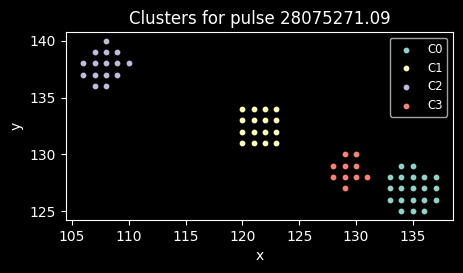

In [5]:
import matplotlib.pyplot as plt

def group_pixels_by_pulse(pixels, pulses):
    pulses_sorted = sorted(pulses)
    grouped = {p: [] for p in pulses_sorted}
    for pix in pixels:
        idx = bisect.bisect_right(pulses_sorted, pix.time_ns) - 1
        if idx < 0:
            continue
        grouped[pulses_sorted[idx]].append(pix)
    return grouped

def cluster_adjacent(points):
    remaining = set(points)
    clusters = []
    while remaining:
        start = remaining.pop()
        stack = [start]
        cluster = [start]
        while stack:
            x, y = stack.pop()
            neighbors = [
                (x + 1, y),
                (x - 1, y),
                (x, y + 1),
                (x, y - 1),
            ]
            for n in neighbors:
                if n in remaining:
                    remaining.remove(n)
                    stack.append(n)
                    cluster.append(n)
        clusters.append(cluster)
    return clusters

pixels_by_pulse_full = group_pixels_by_pulse(pixels, pulses)
cluster_counts = {}
cluster_examples = {}
for pulse_time, pix_list in pixels_by_pulse_full.items():
    points = [(p.x, p.y) for p in pix_list]
    clusters = cluster_adjacent(points) if points else []
    cluster_counts[pulse_time] = [len(c) for c in clusters]
    if clusters:
        cluster_examples[pulse_time] = clusters

total_clusters = sum(len(v) for v in cluster_counts.values())
print(f"Total clusters across all pulses: {total_clusters}")
all_sizes = [size for sizes in cluster_counts.values() for size in sizes]
avg_size = (sum(all_sizes) / len(all_sizes)) if all_sizes else 0
print(f"Average cluster size: {avg_size:.2f}")
first_pulse_with_cluster = None
for pulse_time in sorted(cluster_examples.keys()):
    first_pulse_with_cluster = pulse_time
    break

if first_pulse_with_cluster is not None:
    sizes = sorted(cluster_counts[first_pulse_with_cluster], reverse=True)
    print(f"Pulse {first_pulse_with_cluster} clusters: {len(sizes)}")
    print("Largest cluster sizes:", sizes[:10])
    print("Cluster points (first 3 clusters):")
    for cluster in cluster_examples[first_pulse_with_cluster][:3]:
        print(cluster)
else:
    print("No clusters found.")

if first_pulse_with_cluster is not None:
    clusters = cluster_examples[first_pulse_with_cluster]
    fig, ax = plt.subplots(figsize=(5, 5))
    for idx, cluster in enumerate(clusters):
        xs = [p[0] for p in cluster]
        ys = [p[1] for p in cluster]
        ax.scatter(xs, ys, s=10, label=f"C{idx}")
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Clusters for pulse {first_pulse_with_cluster}")
    if len(clusters) <= 10:
        ax.legend(loc="upper right", fontsize="small")
    plt.show()


In [6]:
import pandas as pd

def cluster_pixels_by_pulse(pixels_by_pulse):
    rows = []
    for pulse_time, pix_list in pixels_by_pulse.items():
        if not pix_list:
            continue
        coord_map = {}
        for pix in pix_list:
            key = (pix.x, pix.y)
            coord_map.setdefault(key, []).append(pix)
        coords = set(coord_map.keys())
        clusters = []
        while coords:
            start = coords.pop()
            stack = [start]
            cluster = [start]
            while stack:
                x, y = stack.pop()
                neighbors = [
                    (x + 1, y),
                    (x - 1, y),
                    (x, y + 1),
                    (x, y - 1),
                ]
                for n in neighbors:
                    if n in coords:
                        coords.remove(n)
                        stack.append(n)
                        cluster.append(n)
            clusters.append(cluster)

        for cluster_id, cluster_coords in enumerate(clusters):
            cluster_pixels = []
            for coord in cluster_coords:
                cluster_pixels.extend(coord_map[coord])
            if not cluster_pixels:
                continue
            weights = [p.tot for p in cluster_pixels]
            weight_sum = sum(weights)
            if weight_sum == 0:
                weights = [1 for _ in cluster_pixels]
                weight_sum = len(cluster_pixels)
            avg_x = sum(p.x * w for p, w in zip(cluster_pixels, weights)) / weight_sum
            avg_y = sum(p.y * w for p, w in zip(cluster_pixels, weights)) / weight_sum
            avg_t = sum((p.time_ns - pulse_time) * w for p, w in zip(cluster_pixels, weights)) / weight_sum
            avg_tot = sum(p.tot * w for p, w in zip(cluster_pixels, weights)) / weight_sum
            rows.append({
                "pulse_time_ns": pulse_time,
                "cluster_id": cluster_id,
                "n_pixels": len(cluster_pixels),
                "weight_sum": weight_sum,
                "avg_x": avg_x,
                "avg_y": avg_y,
                "avg_t_rel_ns": avg_t,
                "avg_tot": avg_tot,
            })
    return pd.DataFrame(rows)

pixels_by_pulse_full = group_pixels_by_pulse(pixels, pulses)
cluster_df = cluster_pixels_by_pulse(pixels_by_pulse_full)
cluster_df.head()


,pulse_time_ns,cluster_id,n_pixels,weight_sum,avg_x,avg_y,avg_t_rel_ns,avg_tot
0,28075271.09,0,20,726,134.767218,126.822314,581.933846,47.027548
1,28075271.09,1,16,485,121.593814,132.468041,574.193505,40.146392
2,28075271.09,2,15,452,107.878319,137.818584,562.365476,37.305310
3,28075271.09,3,10,188,129.228723,128.574468,655.248098,24.095745
4,28090120.83,0,16,459,108.679739,133.993464,574.588028,39.740741


## Notes

- This decoder mirrors the pipeline logic in `tpx_file_decoding.md` (shift by `2**62`).
- The chunk header's first 4 bytes are ignored; bytes 6-7 provide payload length.
- If your file reports headers `0x2` and `0x1` after the shift, the auto-detect will select them.
- Packets are masked to 64-bit unsigned after the `2**62` shift to keep headers in the 0-15 range.
- `sort_tdcs` implements the UConn VMI mapping (types 15/14/10) and returns eTOF, iTOF, pulses.


In [7]:
import time

t0 = time.perf_counter()
pixels, tdcs = decode_tpx3(tpx3_path, max_packets=1000000)
etof, itof, pulses = sort_tdcs(300.0, tdcs)
pixel_times = [p.time_ns for p in pixels]
pixel_rel, pixels_by_pulse = analyze_by_pulse(pixel_times, pulses)
etof_rel, etof_by_pulse = analyze_by_pulse(etof, pulses)
itof_rel, itof_by_pulse = analyze_by_pulse(itof, pulses)
cluster_df = cluster_pixels_by_pulse(group_pixels_by_pulse(pixels, pulses))
elapsed = time.perf_counter() - t0

if pulses:
    real_time = (max(pulses) - min(pulses)) * 1e-9
else:
    real_time = 0.0
ratio = (real_time / elapsed) if elapsed > 0 else 0.0

pulse_count = len(pulses)
pixel_count = len(pixels)
etof_count = len(etof)
itof_count = len(itof)
cluster_count = len(cluster_df)

print(f"Full analysis time: {elapsed:.3f} s")
print(f"Real time span: {real_time:.3f} s")
print(f"Real/analysis ratio: {ratio:.3f}x")
print(f"Pixels: {pixel_count}")
print(f"eTOF: {etof_count}")
print(f"iTOF: {itof_count}")
print(f"Clusters: {cluster_count}")
print(f"Pulses: {pulse_count}")

def per_pulse(count, pulses):
    return (count / pulses) if pulses else 0.0

print(f"Pixels/pulse: {per_pulse(pixel_count, pulse_count):.3f}")
print(f"eTOF/pulse: {per_pulse(etof_count, pulse_count):.3f}")
print(f"iTOF/pulse: {per_pulse(itof_count, pulse_count):.3f}")
print(f"Clusters/pulse: {per_pulse(cluster_count, pulse_count):.3f}")


Full analysis time: 3.915 s
Real time span: 0.457 s
Real/analysis ratio: 0.117x
Pixels: 925116
eTOF: 2303
iTOF: 4389
Clusters: 44723
Pulses: 30750
Pixels/pulse: 30.085
eTOF/pulse: 0.075
iTOF/pulse: 0.143
Clusters/pulse: 1.454


In [11]:
import bisect
import time

def group_times_relative(times, pulses):
    pulses_sorted = sorted(pulses)
    grouped = {p: [] for p in pulses_sorted}
    for t in times:
        idx = bisect.bisect_right(pulses_sorted, t) - 1
        if idx < 0:
            continue
        pulse_time = pulses_sorted[idx]
        grouped[pulse_time].append(t - pulse_time)
    return grouped

def build_pulse_records_relative(pulses, pixels, cluster_df, etof, itof):
    pixels_by_pulse = {p: [] for p in pulses}
    pulses_sorted = sorted(pulses)
    for p in pixels:
        idx = bisect.bisect_right(pulses_sorted, p.time_ns) - 1
        if idx < 0:
            continue
        pulse_time = pulses_sorted[idx]
        pixels_by_pulse[pulse_time].append((p.time_ns - pulse_time, p.x, p.y, p.tot))

    clusters_by_pulse = {}
    for pulse_time, group in cluster_df.groupby("pulse_time_ns"):
        clusters_by_pulse[pulse_time] = group.to_dict("records")

    etof_by_pulse = group_times_relative(etof, pulses_sorted)
    itof_by_pulse = group_times_relative(itof, pulses_sorted)

    records = []
    for pulse_time in pulses_sorted:
        records.append((
            pulse_time,
            pixels_by_pulse.get(pulse_time, []),
            clusters_by_pulse.get(pulse_time, []),
            etof_by_pulse.get(pulse_time, []),
            itof_by_pulse.get(pulse_time, []),
        ))
    return records

tpx3_path = r"Test Data\large_test_file.tpx3"
t0 = time.perf_counter()
pixels, tdcs = decode_tpx3(tpx3_path, max_packets=10_000)
etof, itof, pulses = sort_tdcs(300.0, tdcs)
cluster_df = cluster_pixels_by_pulse(group_pixels_by_pulse(pixels, pulses))
pulse_records_rel = build_pulse_records_relative(pulses, pixels, cluster_df, etof, itof)
elapsed = time.perf_counter() - t0
print(f"Built {len(pulse_records_rel)} pulse records from 10,000 packets in {elapsed:.3f} s")
print("First record (pulse time, counts):", pulse_records_rel[0][0], len(pulse_records_rel[0][1]), len(pulse_records_rel[0][2]), len(pulse_records_rel[0][3]), len(pulse_records_rel[0][4]))


Built 324 pulse records from 10,000 packets in 0.205 s
First record (pulse time, counts): 28060420.83 0 0 0 0


In [12]:
def summarize_pulse_records(pulse_records):
    total = len(pulse_records)
    if total == 0:
        return {}
    any_etof = 0
    any_itof = 0
    any_cluster = 0
    multi_etof = 0
    multi_itof = 0
    multi_cluster = 0
    all_three = 0
    cluster_sizes = []
    total_etof = 0
    total_itof = 0
    total_clusters = 0

    for _, _, clusters, etofs, itofs in pulse_records:
        has_etof = len(etofs) > 0
        has_itof = len(itofs) > 0
        has_cluster = len(clusters) > 0

        any_etof += 1 if has_etof else 0
        any_itof += 1 if has_itof else 0
        any_cluster += 1 if has_cluster else 0

        multi_etof += 1 if len(etofs) > 1 else 0
        multi_itof += 1 if len(itofs) > 1 else 0
        multi_cluster += 1 if len(clusters) > 1 else 0

        all_three += 1 if (has_etof and has_itof and has_cluster) else 0

        total_etof += len(etofs)
        total_itof += len(itofs)
        total_clusters += len(clusters)
        for cluster in clusters:
            if isinstance(cluster, dict) and "n_pixels" in cluster:
                cluster_sizes.append(cluster["n_pixels"])

    avg_cluster_size = (sum(cluster_sizes) / len(cluster_sizes)) if cluster_sizes else 0
    cluster_to_etof = (total_clusters / total_etof) if total_etof else 0
    cluster_to_itof = (total_clusters / total_itof) if total_itof else 0

    return {
        "total_pulses": total,
        "ratio_any_etof": any_etof / total,
        "ratio_any_itof": any_itof / total,
        "ratio_any_cluster": any_cluster / total,
        "ratio_multi_etof": multi_etof / total,
        "ratio_multi_itof": multi_itof / total,
        "ratio_multi_cluster": multi_cluster / total,
        "ratio_all_three": all_three / total,
        "avg_cluster_size": avg_cluster_size,
        "cluster_to_etof": cluster_to_etof,
        "cluster_to_itof": cluster_to_itof,
    }

stats = summarize_pulse_records(pulse_records_rel)
for key, value in stats.items():
    if key.startswith("ratio_") or key.endswith("to_etof") or key.endswith("to_itof"):
        print(f"{key}: {value:.3f}")
    else:
        print(f"{key}: {value}")


total_pulses: 324
ratio_any_etof: 0.071
ratio_any_itof: 0.142
ratio_any_cluster: 0.586
ratio_multi_etof: 0.000
ratio_multi_itof: 0.003
ratio_multi_cluster: 0.340
ratio_all_three: 0.031
avg_cluster_size: 19.806451612903224
cluster_to_etof: 20.217
cluster_to_itof: 9.894
